# Razors Edge Real Gpu Contours

Shows the Razor's Edge contours for `RazorsEdgeGPUBenchmarkTask`.


In [1]:
from pathlib import Path
import sys
import psutil
import os

repo_root = Path.cwd()

while not (repo_root / "src").exists():
    if repo_root.parent == repo_root:
        raise RuntimeError("Could not find 'src' directory in any parent")
    repo_root = repo_root.parent

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

p = psutil.Process(os.getpid())
if psutil.WINDOWS:
    p.nice(psutil.HIGH_PRIORITY_CLASS)
else:
    try:
        p.nice(-10)
    except psutil.AccessDenied:
        print("Elevation (sudo) is required to set high priority on Unix.")

In [2]:
from concurrent.futures import ThreadPoolExecutor

import matplotlib.pyplot as plt
import numpy as np

from demos.real.razors_edge_gpu_benchmark_task import RazorsEdgeGPUBenchmarkTask
from src.razors_edge.optimal_batching import _compiled_dynamic_batcher

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

e:\Github\Razors-Edge-batching-scheduler-v0\src\razors_edge\optimal_benchmarking.py:45: UserWarning: 
The maximal number of iterations maxit (set to 20 by the program)
allowed for finding a smoothing spline with fp=s has been reached: s
too small.
There is an approximation returned but the corresponding weighted sum
of squared residuals does not satisfy the condition abs(fp-s)/s < tol.
  spline1 = UnivariateSpline(first_benchmark_points, first_benchmark_timings, k=spline_k, s=spline_s)
e:\Github\Razors-Edge-batching-scheduler-v0\src\razors_edge\optimal_benchmarking.py:46: UserWarning: 
The maximal number of iterations maxit (set to 20 by the program)
allowed for finding a smoothing spline with fp=s has been reached: s
too small.
There is an approximation returned but the corresponding weighted sum
of squared residuals does not satisfy the condition abs(fp-s)/s < tol.
  spline2 = UnivariateSpline(second_benchmark_points, second_benchmark_timings, k=spline_k, s=spline_s)
e:\Github\Razors

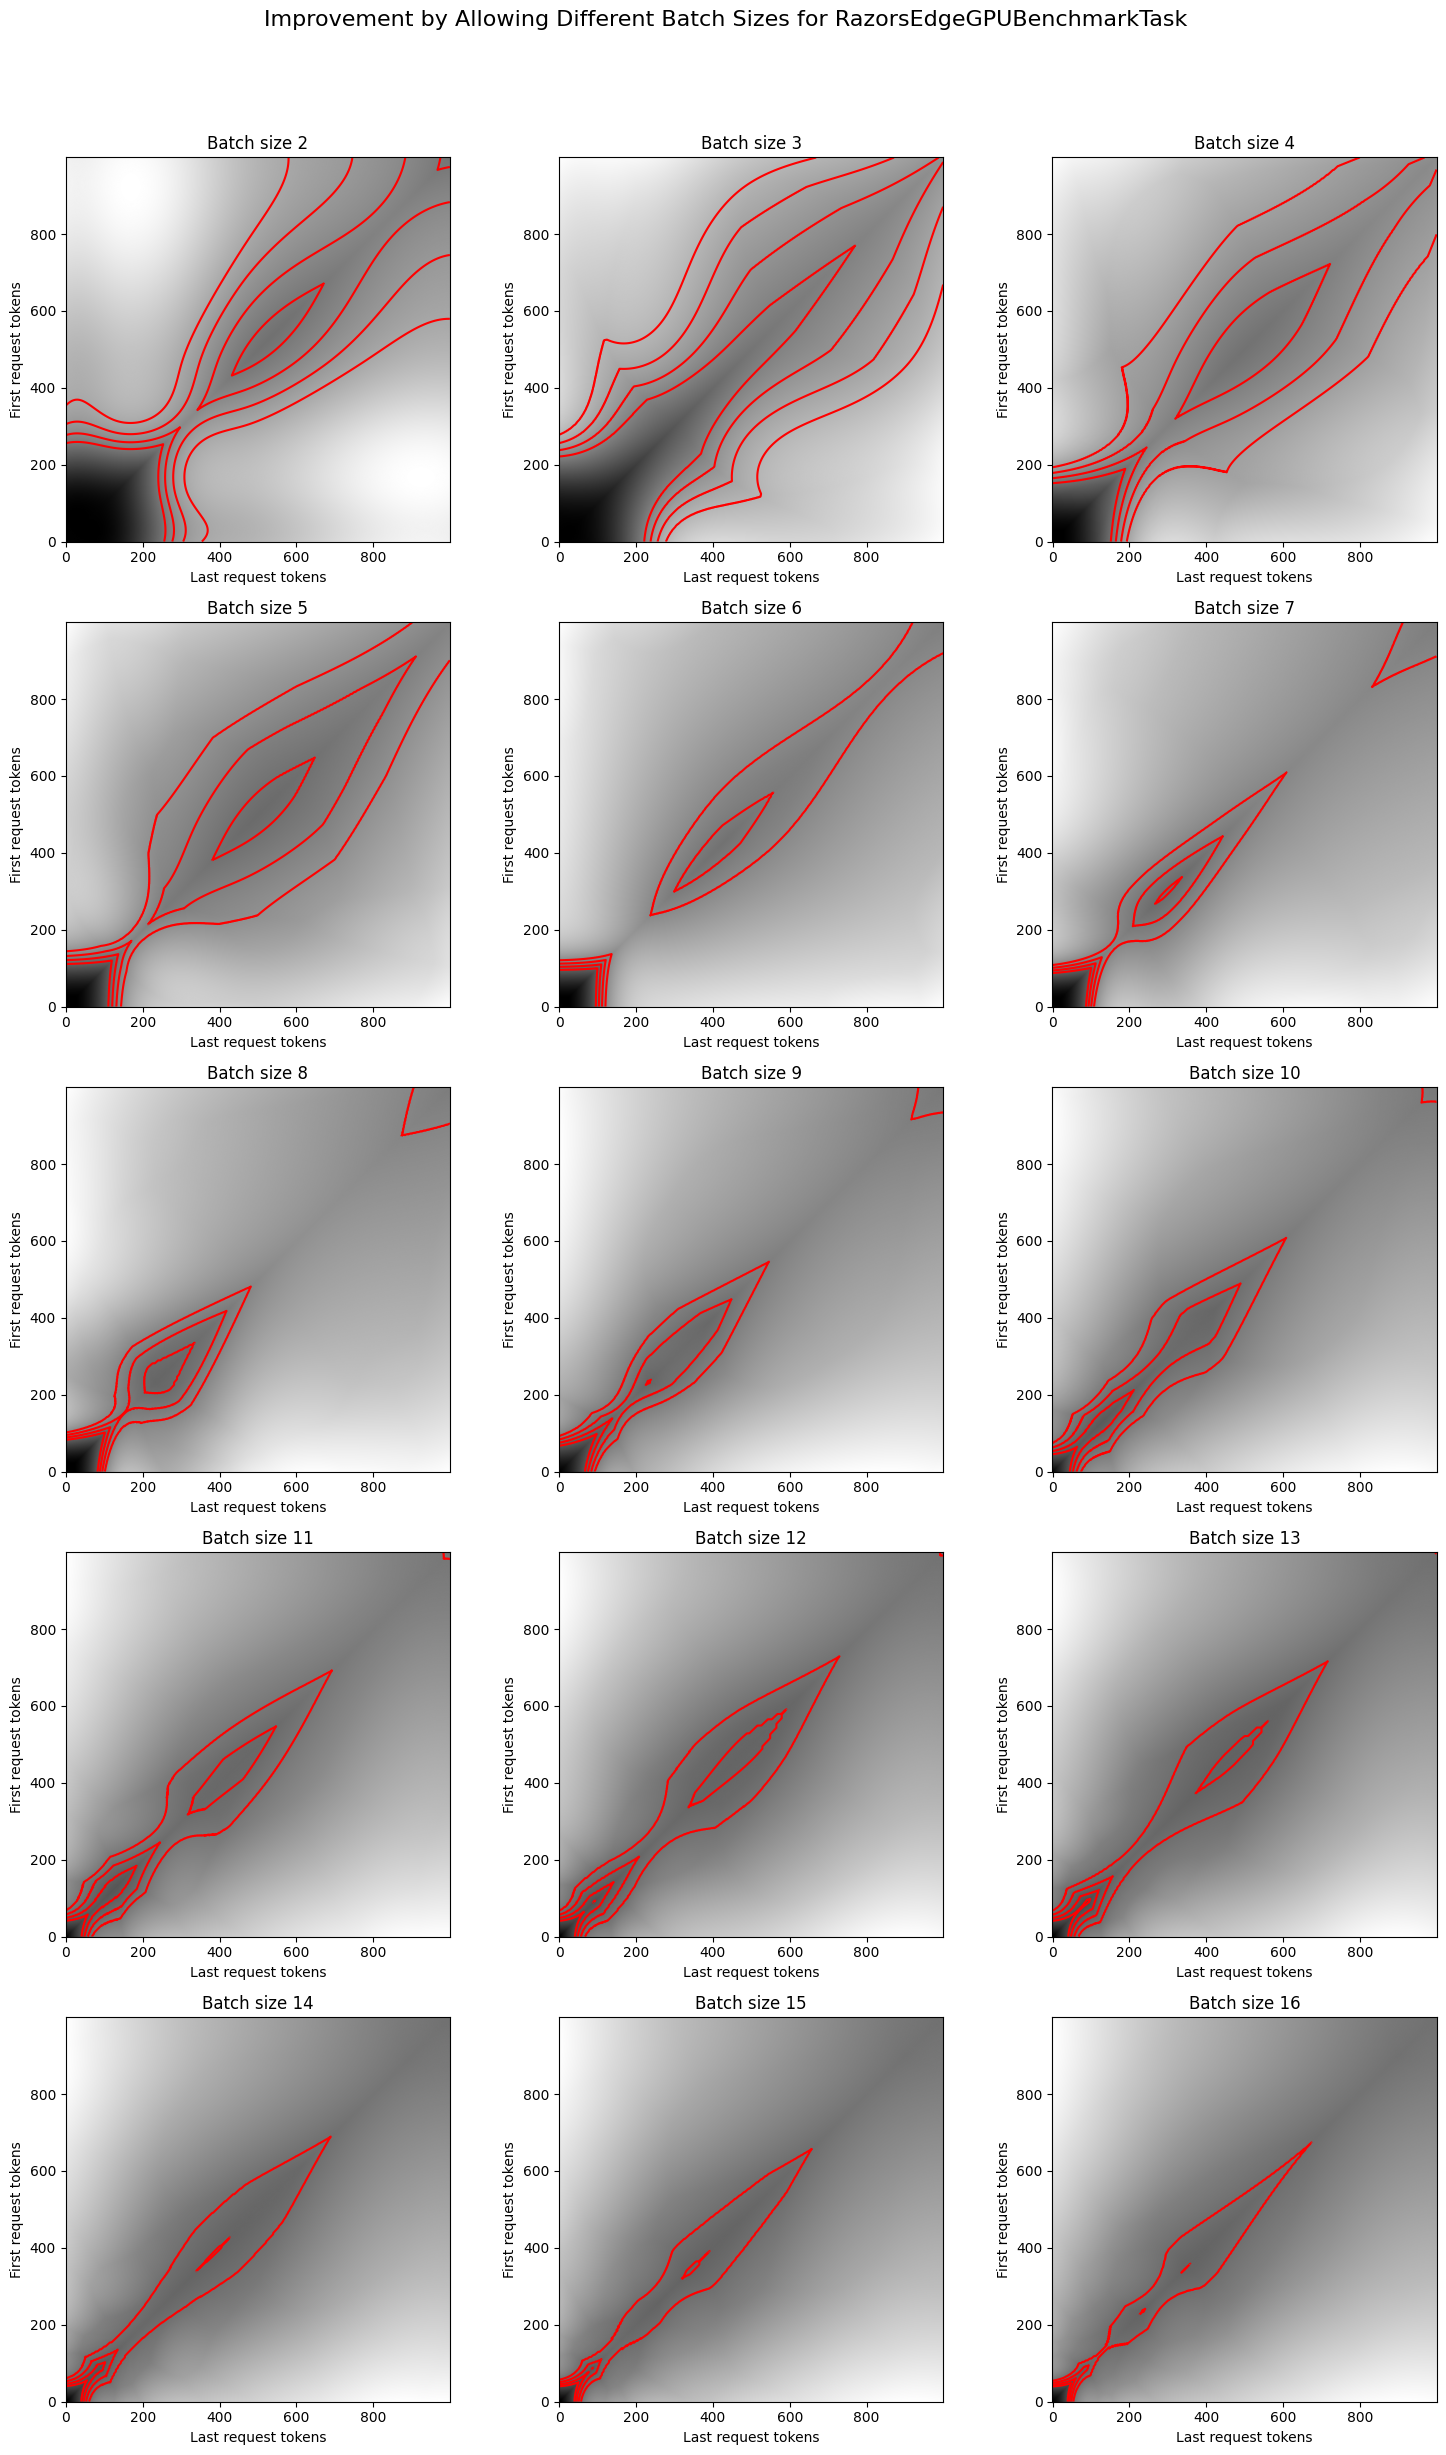

In [3]:
initialized_task = RazorsEdgeGPUBenchmarkTask(ThreadPoolExecutor(1))
batch_sizes = range(2, initialized_task.batch_benchmark_sizes[-1]+1)
num_batches = len(batch_sizes)

cols = 3
rows = int(np.ceil(num_batches / cols))

fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 5*rows))
axes = axes.flatten()  # Flatten to simplify indexing

for idx, allowed_batch_size in enumerate(batch_sizes):
    image = np.zeros((1000, 1000), dtype=np.float32)
    for i in range(1000):
        for j in range(i+1):
            tokens = np.linspace(j, i, allowed_batch_size).astype(np.uint32)
            time_ratio = initialized_task.batch_timing_estimators[allowed_batch_size-1, i] / _compiled_dynamic_batcher(tokens, initialized_task.batch_timing_estimators[:allowed_batch_size-1])[0][-1]
            image[i, j] = time_ratio
            image[j, i] = time_ratio

    ax = axes[idx]
    ax.set_title(f"Batch size {allowed_batch_size}")
    ax.set_ylabel("First request tokens")
    ax.set_xlabel("Last request tokens")
    im = ax.imshow(image, origin='lower', cmap='gray')
    ax.contour(image, levels=[0.85, 0.9, 0.95, 1], colors='red')

# Turn off any unused subplots
for ax in axes[num_batches:]:
    ax.axis('off')

fig.suptitle("Improvement by Allowing Different Batch Sizes for RazorsEdgeGPUBenchmarkTask", fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.95])  # leave space for the suptitle
fig.savefig(Path("..") / ".." / "images" / f"{fig.get_suptitle()}.png")
plt.show()